WEEK 2 STARK AI ASSIGNMENT/PROJECT(SSSC AI/ML)(2026):

NAME: SUDIKSHA DAS

ENROLLMENT NO.: 19901172025

(Week 1 Concepts Included)

Dataset:
(A sample of dataset for its format)

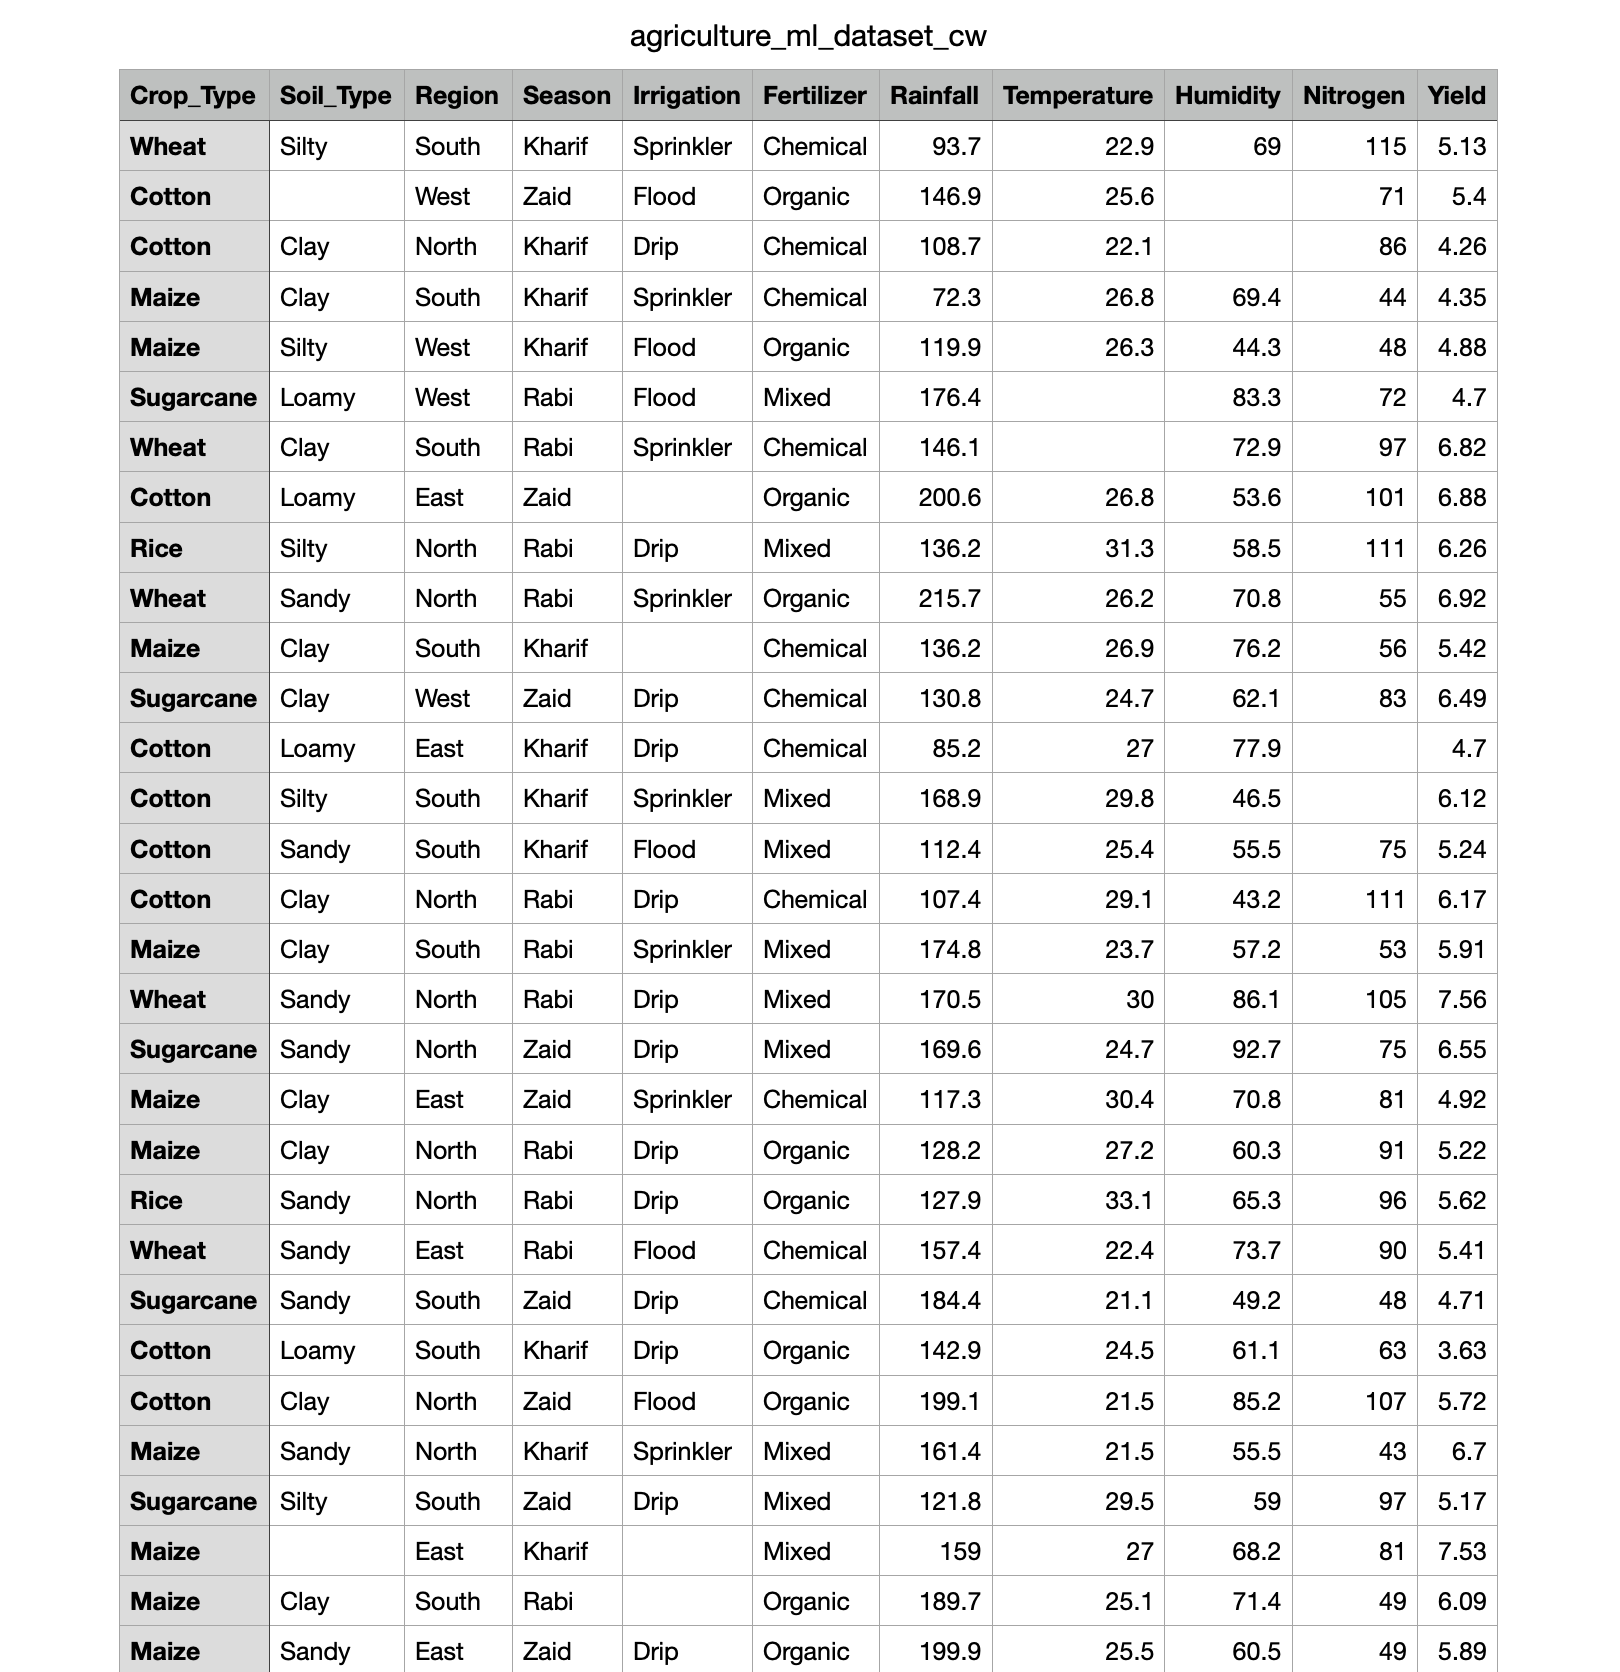

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("agriculture_ml_dataset_cw.csv")

#After loading the data we are gonna take out further more info and check for missing and duplicate values of dataset and correcting them before building model.

In [ ]:
df.head()

,Crop_Type,Soil_Type,Region,Season,Irrigation,Fertilizer,Rainfall,Temperature,Humidity,Nitrogen,Yield
0,Wheat,Silty,South,Kharif,Sprinkler,Chemical,93.7,22.9,69.0,115.0,5.13
1,Cotton,NaN,West,Zaid,Flood,Organic,146.9,25.6,NaN,71.0,5.40
2,Cotton,Clay,North,Kharif,Drip,Chemical,108.7,22.1,NaN,86.0,4.26
3,Maize,Clay,South,Kharif,Sprinkler,Chemical,72.3,26.8,69.4,44.0,4.35
4,Maize,Silty,West,Kharif,Flood,Organic,119.9,26.3,44.3,48.0,4.88


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Crop_Type    2020 non-null   object 
 1   Soil_Type    1899 non-null   object 
 2   Region       2020 non-null   object 
 3   Season       2020 non-null   object 
 4   Irrigation   1900 non-null   object 
 5   Fertilizer   2020 non-null   object 
 6   Rainfall     1899 non-null   float64
 7   Temperature  1900 non-null   float64
 8   Humidity     1898 non-null   float64
 9   Nitrogen     1899 non-null   float64
 10  Yield        2020 non-null   float64
dtypes: float64(5), object(6)
memory usage: 173.7+ KB


In [ ]:
df.describe()

,Rainfall,Temperature,Humidity,Nitrogen,Yield
count,1899.000000,1900.000000,1898.000000,1899.000000,2020.000000
mean,129.723960,26.875421,67.740622,79.169036,5.442926
std,35.395931,4.104174,12.046501,22.876734,1.062772
min,22.800000,12.900000,30.600000,40.000000,1.740000
25%,107.100000,24.200000,59.500000,59.000000,4.700000
50%,128.100000,26.900000,67.650000,79.000000,5.430000
75%,153.500000,29.600000,75.800000,99.000000,6.172500
max,245.300000,43.100000,117.800000,119.000000,8.910000


In [ ]:
df.shape

(2020, 11)

In [ ]:
df.columns

Index(['Crop_Type', 'Soil_Type', 'Region', 'Season', 'Irrigation',
       'Fertilizer', 'Rainfall', 'Temperature', 'Humidity', 'Nitrogen',
       'Yield'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Crop_Type,0
Soil_Type,121
Region,0
Season,0
Irrigation,120
Fertilizer,0
Rainfall,121
Temperature,120
Humidity,122
Nitrogen,121


In [ ]:
#Handling missing values

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

cat_cols = df.select_dtypes(include=['object']).columns

df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [ ]:
df.isnull().sum()

,0
Crop_Type,0
Soil_Type,0
Region,0
Season,0
Irrigation,0
Fertilizer,0
Rainfall,0
Temperature,0
Humidity,0
Nitrogen,0


In [ ]:
df.duplicated().sum()

np.int64(20)

In [ ]:
#Removing duplicate rows

df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
X = df.drop("Yield", axis=1)

y = df["Yield"]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
m = len(X_train)
print("Number of training examples (m):", m)

#Similarly for others given below

Number of training examples (m): 1600


In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1600, 20), (400, 20), (1600,), (400,))

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

#Starting to build Linear Regression Model

LinearRegression()

In [ ]:
#weight(w) and bias(b) are both parts of linear regression mathematical equation.
#Where w is coefficient or slope and b is intercept.

def compute_model_output(X, w, b):
    predictions = []

    for i in range(len(X)):
        prediction = np.dot(X.iloc[i], w) + b
        predictions.append(prediction)

    return np.array(predictions)

In [ ]:
w = model.coef_
b = model.intercept_

y_pred = compute_model_output(X_test, w, b)

In [ ]:
y_pred = compute_model_output(X_test, w, b)

print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[5.55453198 5.35919721 6.42760332 6.10288541 6.12182917 6.19955368
 5.68329267 5.24556867 5.74162969 5.29189119]


In [ ]:
#Comparing Actual Vs Predicted:

comparison = pd.DataFrame({
    "Actual Yield": y_test.values,
    "Predicted Yield": y_pred
})

comparison.head(10)

,Actual Yield,Predicted Yield
0,5.99,5.554532
1,6.23,5.359197
2,6.89,6.427603
3,6.13,6.102885
4,6.72,6.121829
5,6.68,6.199554
6,3.92,5.683293
7,5.85,5.245569
8,4.41,5.741630
9,6.04,5.291891


In [ ]:
#The concept of performance metrics taught in week1


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.6403450547755498
Mean Squared Error (MSE): 0.6361942250700299
Root Mean Squared Error (RMSE): 0.7976178440017687
R² Score: 0.40034476205673497


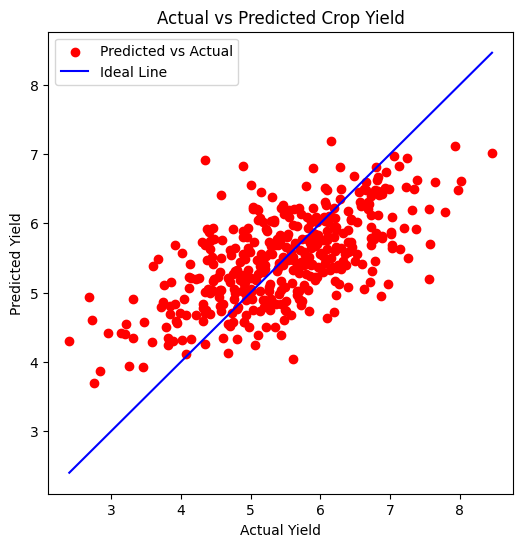

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, color="red", label="Predicted vs Actual")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="blue",
         label="Ideal Line")

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Crop Yield")

plt.legend()

plt.show()

In [ ]:
X.columns.tolist()

['Rainfall',
 'Temperature',
 'Humidity',
 'Nitrogen',
 'Crop_Type_Maize',
 'Crop_Type_Rice',
 'Crop_Type_Sugarcane',
 'Crop_Type_Wheat',
 'Soil_Type_Loamy',
 'Soil_Type_Sandy',
 'Soil_Type_Silty',
 'Region_North',
 'Region_South',
 'Region_West',
 'Season_Rabi',
 'Season_Zaid',
 'Irrigation_Flood',
 'Irrigation_Sprinkler',
 'Fertilizer_Mixed',
 'Fertilizer_Organic']

In [ ]:
#Inorder to predict yield for a new sample.

new_sample = pd.DataFrame(0, index=[0], columns=X.columns)

new_sample["Rainfall"] = 150
new_sample["Temperature"] = 28
new_sample["Humidity"] = 70
new_sample["Nitrogen"] = 90

new_sample["Crop_Type_Wheat"] = 1
new_sample["Soil_Type_Loamy"] = 1
new_sample["Region_South"] = 1
new_sample["Season_Rabi"] = 1
new_sample["Irrigation_Sprinkler"] = 1
new_sample["Fertilizer_Organic"] = 1

new_prediction = compute_model_output(new_sample, w, b)

print("Predicted Crop Yield:", new_prediction[0])

Predicted Crop Yield: 5.972330355927609


Hence, our value for Crop Yield got predicted.